In [5]:
import pandas as pd
import os

save_folders = ["2025_09_04_beta1.0_2BS_20UE_10RIS_250M", "2025_09_04_beta1.2_2BS_20UE_10RIS_250M",
                "2025_09_04_beta1.5_2BS_20UE_10RIS_250M", "2025_09_04_beta2.0_2BS_20UE_10RIS_250M",
                "2025_09_04_beta3.0_2BS_20UE_10RIS_250M", "2025_09_04_beta4.0_2BS_20UE_10RIS_250M",
                "2025_09_04_beta5.0_2BS_20UE_10RIS_250M", "2025_09_04_beta7.0_2BS_20UE_10RIS_250M",
                "2025_09_04_beta10.0_2BS_20UE_10RIS_250M", "2025_09_04_beta12.0_2BS_20UE_10RIS_250M",
                "2025_09_04_beta15.0_2BS_20UE_10RIS_250M", "2025_09_04_beta18.0_2BS_20UE_10RIS_250M"]

save_folders = [os.path.join(os.pardir, "results", folder) for folder in save_folders]
file_name = "Data.csv"

for i, folder in enumerate(save_folders):
    df = pd.read_csv(os.path.join(folder, file_name), index_col=0)
    df["Efficiency"] = df["Sum rate"] / df["Cost"]
    if i == 0:
        data = df
    else:
        data = data._append(df.iloc[0])

data.sort_index(inplace=True)
data


,Sum rate,Cost,Number of RISs allocated,Bid value,Efficiency
Distance-based,5.611666,0.556125,3.2700,0.562862,10.090657
Greedy,5.983151,0.608875,3.3100,0.768354,9.826567
RL beta 1.0,6.209097,0.854875,4.3575,0.687147,7.263164
RL beta 1.2,6.235671,0.814000,4.2975,0.740309,7.660529
RL beta 1.5,6.219735,0.832375,4.3550,0.712627,7.472275
RL beta 10.0,5.413083,0.117125,2.3100,0.819277,46.216292
RL beta 12.0,5.428223,0.105500,2.1100,0.862560,51.452350
RL beta 15.0,5.292319,0.078500,1.5675,0.947341,67.418072
RL beta 18.0,5.018317,0.056625,1.1325,0.991370,88.623697
RL beta 2.0,6.215966,0.707125,3.9850,0.793383,8.790478


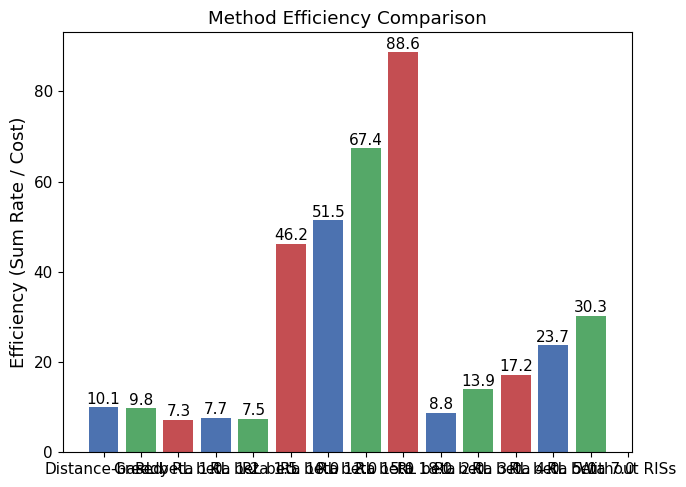

In [6]:
import matplotlib.pyplot as plt

df = data

plt.figure(figsize=(7,5))
bars = plt.bar(df.index, df["Efficiency"], color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylabel("Efficiency (Sum Rate / Cost)")
plt.title("Method Efficiency Comparison")

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.1f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("efficiency", dpi=300, bbox_inches="tight")  
plt.show()

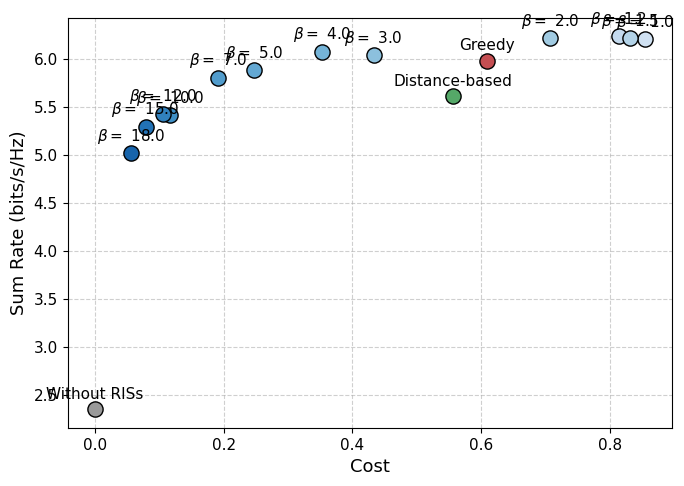

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 11,       # default text size
    "axes.labelsize": 13,  # x/y-axis labels
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11  # legend text size
})

# --- Filter out unwanted models ---
# df_plot = df.drop(index=["RL beta 1.2", "RL beta 1.5", "RL beta 10.0", "RL beta 15.0"], errors="ignore")
df_plot = df
plt.figure(figsize=(7,5))

# --- Assign colors by method family ---
colors = {}
colors["Distance-based"] = "#55A868"   # green
colors["Greedy"] = "#C44E52"           # red
colors["Without RISs"] = "#999999"     # grey

# RL models with stronger gradient
rl_methods = [m for m in df_plot.index if "RL beta" in m]
blue_cmap = plt.cm.Blues(np.linspace(0.2, 0.8, len(rl_methods)))
for method, c in zip(sorted(rl_methods, key=lambda x: float(x.split()[2])), blue_cmap):
    colors[method] = c

# --- Plot points ---
for i, (method_name, row) in enumerate(df_plot.iterrows()):
    plt.scatter(row["Cost"], row["Sum rate"],
                color=colors[method_name], s=120, edgecolors="black", zorder=3)

# --- Annotate: use Greek β for RL models ---
for method_name, row in df_plot.iterrows():
    label = method_name
    if "RL beta" in method_name:
        val = method_name.split()[-1]   # get the numeric part
        label = rf"$\beta=$ {val}"       # LaTeX string with Greek beta
    
    dy = 0.08   # vertical offset
    plt.text(row["Cost"], row["Sum rate"]+dy,
             label, ha="center", va="bottom")


# --- Labels and styling ---
plt.xlabel("Cost")
plt.ylabel("Sum Rate (bits/s/Hz)")
plt.grid(True, linestyle="--", alpha=0.6, zorder=0)
plt.tight_layout()

plt.savefig("cost_vs_sum_rate.png", dpi=300, bbox_inches="tight")
plt.show()


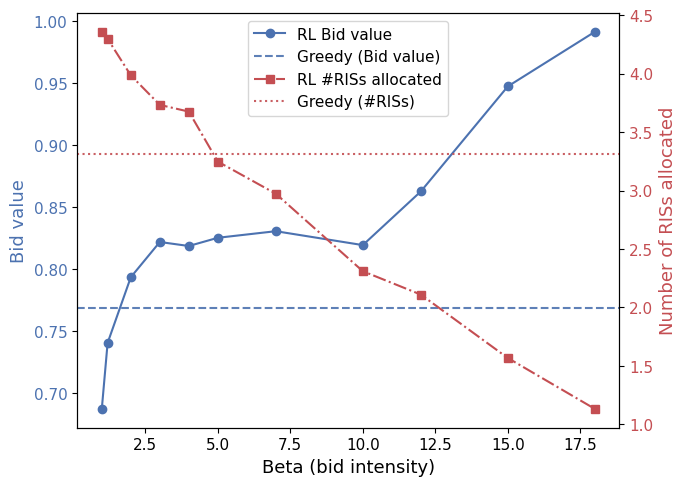

In [8]:
import matplotlib.pyplot as plt

# --- Extract RL runs ---
rl_df = df[df.index.str.contains("RL beta")].copy()
rl_df["beta"] = [float(rl_df.index[i].split(" ")[2]) for i in range(len(rl_df))]
rl_df = rl_df.drop(index=["RL beta 1.5"], errors="ignore")

rl_df.sort_values("beta", inplace=True)

# --- Baselines ---
baseline_df = df[~df.index.str.contains("RL beta")]
# Drop "Without RISs" row
baseline_df = baseline_df[~baseline_df.index.isin(["Without RISs", "Distance-based"])]

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(7,5))

color1 = "#4C72B0"   # bid value
color2 = "#C44E52"   # RISs allocated

# Left y-axis: Bid value
ax1.plot(rl_df["beta"], rl_df["Bid value"], marker="o", color=color1, label="RL Bid value")
ax1.set_xlabel("Beta (bid intensity)")
ax1.set_ylabel("Bid value", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

# Add baseline horizontal lines for Bid value
for method, row in baseline_df.iterrows():
    ax1.axhline(y=row["Bid value"], linestyle="--", alpha=0.9,
                color=color1, label=f"{method} (Bid value)")

# Right y-axis: Number of RISs allocated
ax2 = ax1.twinx()
ax2.plot(rl_df["beta"], rl_df["Number of RISs allocated"], marker="s", linestyle="-.",
         color=color2, label="RL #RISs allocated")
ax2.set_ylabel("Number of RISs allocated", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

# Add baseline horizontal lines for RISs allocated
for method, row in baseline_df.iterrows():
    ax2.axhline(y=row["Number of RISs allocated"], linestyle=":", alpha=0.9,
                color=color2, label=f"{method} (#RISs)")

fig.tight_layout()

# Deduplicate legend entries
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
by_label = dict(zip(labels1+labels2, handles1+handles2))
ax1.legend(by_label.values(), by_label.keys(), loc="upper center")

plt.savefig("beta_effects_with_baselines", dpi=300, bbox_inches="tight")
plt.show()


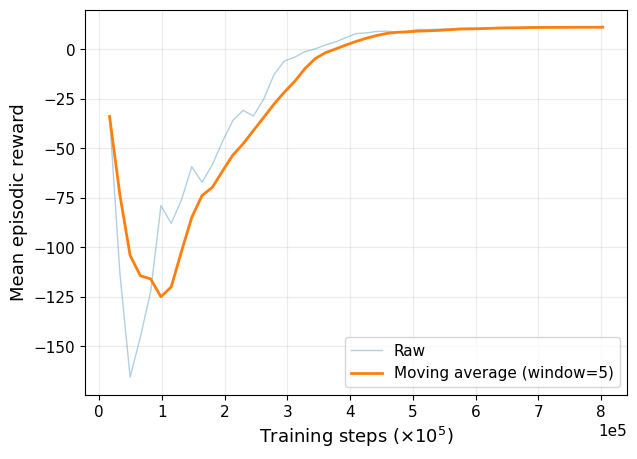

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Load TensorBoard-exported CSV
df = pd.read_csv("log_PPO_0.csv").sort_values("Step").reset_index(drop=True)

# Simple moving-average smoothing (for readability)
window = 5
df["smoothed"] = df["Value"].rolling(window=window, min_periods=1).mean()

plt.figure(figsize=(7,5))
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

plt.plot(df["Step"], df["Value"], label="Raw", linewidth=1, alpha=0.35)
plt.plot(df["Step"], df["smoothed"], label=f"Moving average (window={window})", linewidth=2)

plt.xlabel(r"Training steps ($\times 10^{5}$)")
plt.ylabel("Mean episodic reward")
plt.grid(True, which="both", alpha=0.25)
plt.legend(frameon=True)

# ---- Scientific notation for x-axis ----
ax = plt.gca()
ax.ticklabel_format(style="sci", axis="x", scilimits=(5,5))
ax.xaxis.get_offset_text().set_size(11)

plt.savefig("ppo_gamma2_convergence.png", dpi=300, bbox_inches="tight")
plt.show()


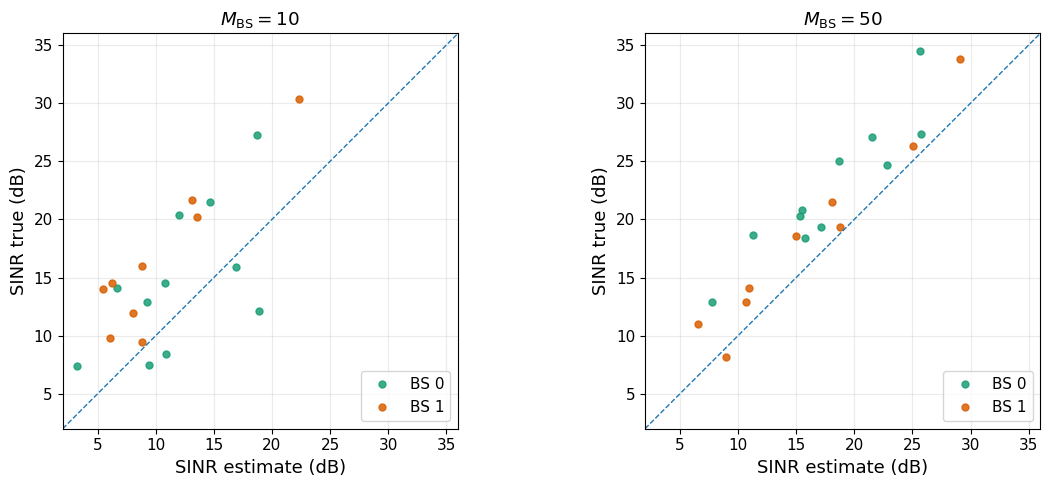

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------- PATHS ----------
folder = "2025_09_04_beta2.0_2BS_20UE_10RIS_250M"
base_dir = os.path.join(os.pardir, "results", folder)

csv_10 = os.path.join(base_dir, "sinr_accuracy_MBS10.csv")
csv_50 = os.path.join(base_dir, "sinr_accuracy_MBS50.csv")

df10 = pd.read_csv(csv_10)
df50 = pd.read_csv(csv_50)

# --------- PLOT STYLE ----------
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

# --------- CONSISTENT AXIS LIMITS (for fair comparison) ----------
all_vals = pd.concat([
    df10[["sinr_est_db", "sinr_true_db"]],
    df50[["sinr_est_db", "sinr_true_db"]]
], axis=0)

vmin = float(np.floor(all_vals.min().min()))
vmax = float(np.ceil(all_vals.max().max()))

# Add a small padding
pad = 1.0
vmin -= pad
vmax += pad

def scatter_by_bs(ax, df, title):
    # color points by BS index (if present); otherwise just plot all points
    if "bs" in df.columns:
        bs_list = sorted(df["bs"].unique())
        colors = plt.colormaps["Dark2"].colors
        for i, bs in enumerate(bs_list):
            sub = df[df["bs"] == bs]
            ax.plot(
                sub["sinr_est_db"], sub["sinr_true_db"],
                "o", markersize=5, alpha=0.85,
                color=colors[i % len(colors)],
                label=f"BS {bs}"
            )
        ax.legend(frameon=True, loc="lower right")
    else:
        ax.plot(df["sinr_est_db"], df["sinr_true_db"], "o", markersize=5, alpha=0.85)

    # y = x reference
    ax.plot([vmin, vmax], [vmin, vmax], linestyle="--", linewidth=1)

    ax.set_title(title)
    ax.set_xlabel("SINR estimate (dB)")
    ax.set_ylabel("SINR true (dB)")
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)

# --------- FIGURE ----------
plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)
scatter_by_bs(ax1, df10, r"$M_{\mathrm{BS}}=10$")

ax2 = plt.subplot(1, 2, 2)
scatter_by_bs(ax2, df50, r"$M_{\mathrm{BS}}=50$")

plt.tight_layout()
plt.savefig("sinr_accuracy_mbs10_vs_mbs50.png", dpi=300, bbox_inches="tight")
plt.show()


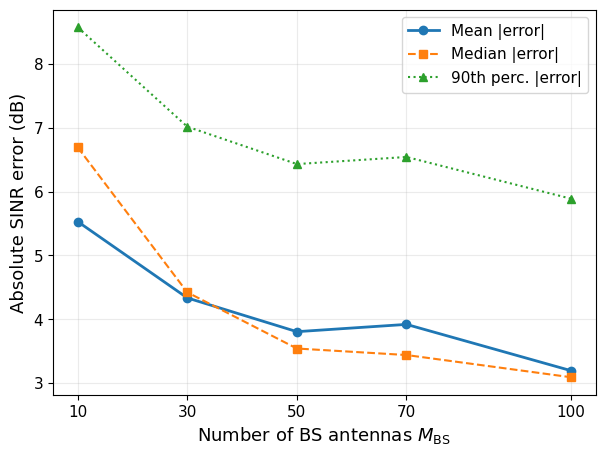

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------- PATHS ----------
folder = "2025_09_04_beta2.0_2BS_20UE_10RIS_250M"
base_dir = os.path.join(os.pardir, "results", folder)

mbs_list = [10, 30, 50, 70, 100]
csv_paths = {
    mbs: os.path.join(base_dir, f"sinr_accuracy_MBS{mbs}.csv")
    for mbs in mbs_list
}

# --------- LOAD + AGGREGATE ----------
rows = []
for mbs in mbs_list:
    df = pd.read_csv(csv_paths[mbs])
    if "abs_err_db" not in df.columns:
        raise ValueError(f"'abs_err_db' column not found in {csv_paths[mbs]}")

    abs_err = df["abs_err_db"].to_numpy(dtype=float)

    rows.append({
        "MBS": mbs,
        "mean_abs_err_db": float(np.mean(abs_err)),
        "median_abs_err_db": float(np.median(abs_err)),
        "p90_abs_err_db": float(np.percentile(abs_err, 90))
    })

summary = pd.DataFrame(rows).sort_values("MBS")

# --------- PLOT STYLE ----------
plt.figure(figsize=(7, 5))
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

# Main trend (mean abs error)
plt.plot(
    summary["MBS"], summary["mean_abs_err_db"],
    marker="o", linewidth=2, label="Mean |error|"
)

# Optional: show median and 90th percentile for robustness
plt.plot(
    summary["MBS"], summary["median_abs_err_db"],
    marker="s", linewidth=1.5, linestyle="--", label="Median |error|"
)
plt.plot(
    summary["MBS"], summary["p90_abs_err_db"],
    marker="^", linewidth=1.5, linestyle=":", label="90th perc. |error|"
)

plt.xlabel(r"Number of BS antennas $M_{\mathrm{BS}}$")
plt.ylabel(r"Absolute SINR error (dB)")
plt.xticks(mbs_list)
plt.grid(True, alpha=0.25)
plt.legend(frameon=True)

plt.savefig("sinr_accuracy_trend_vs_mbs.png", dpi=300, bbox_inches="tight")
plt.show()
